##### 3. Univariate Exploratory Data Analysis

###### Objective

The purpose of this notebook is to examine the distribution and characteristics of each important variable in the Netflix dataset independently. Univariate Exploratory Data Analysis (EDA) provides a foundational understanding of the dataset by identifying dominant categories, trends, frequency distributions, and potential anomalies before exploring relationships between multiple variables.

The analysis focuses on understanding how Netflix's content is distributed across categories, genres, countries, ratings, release years, durations, and other key attributes. The insights obtained from this stage serve as the basis for the subsequent bivariate and multivariate analyses.

---

##### Investigation Questions Addressed

This notebook answers the following investigation questions:

##### Question 1

**What is the distribution of Movies versus TV Shows in Netflix's catalog?**

* Count the number of Movies and TV Shows.
* Calculate their percentage distribution.
* Identify the dominant content category.

---

##### Question 2

**Which genres or content types are most prevalent in Netflix's library?**

* Split the `Type` column into individual genres.
* Calculate the frequency of each genre.
* Rank genres by occurrence.
* Identify the most and least common genres.

---

##### Question 3

**How has Netflix's content volume changed over time (by release year)?**

* Extract the release year from the `Release_Date` column.
* Count the number of titles released each year.
* Visualize growth trends over time.
* Identify years of rapid expansion or decline.

---

##### Question 4

**Which countries produce the most content available on Netflix?**

* Split multiple-country entries into individual countries.
* Count titles associated with each country.
* Rank countries by content volume.
* Identify the leading content-producing regions.

---

##### Additional Univariate Analysis

In addition to the investigation questions, this notebook also examines the following variables individually:

* Content Ratings
* Movie Duration Distribution
* TV Show Season Distribution
* Top Directors
* Top Cast Members
* Release Month Distribution (if applicable)
* Description Length Distribution
* Title Length Distribution (optional)

---

##### Expected Outcomes

Upon completion of this notebook, we will have:

* A clear understanding of Netflix's content composition.
* Identification of the most common genres, countries, and ratings.
* Insights into Netflix's content growth over time.
* A statistical overview of content duration and other important attributes.
* A strong foundation for the relationship analyses performed in the following notebooks.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

In [ ]:
# Visualization Settings
plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [12]:
# Helper Function: Plot Count Bar Chart

def plot_count_bar(data, title, xlabel, ylabel, color="steelblue"):
    """
    Plots a count bar chart with value labels.

    Parameters
    ----------
    data : pandas.Series
        Series containing category counts.
    title : str
        Plot title.
    xlabel : str
        Label for x-axis.
    ylabel : str
        Label for y-axis.
    color : str, default='steelblue'
        Bar color.
    """

    plt.figure(figsize=(8,5))

    ax = data.plot(
        kind="bar",
        color=color,
        edgecolor="black"
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    for container in ax.containers:
        ax.bar_label(container)

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [14]:
# Helper Function: Pie Chart
def plot_pie_chart(data, title):
    """
    Plots a pie chart showing percentage distribution.

    Parameters
    ----------
    data : pandas.Series
        Series containing category counts.
    title : str
        Plot title.
    """

    plt.figure(figsize=(6,6))

    plt.pie(
        data,
        labels=data.index,
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor":"black"}
    )

    plt.title(title, fontweight="bold")

    plt.tight_layout()
    plt.show()

In [20]:
# Helper Function: Horizontal Bar Chart
def plot_horizontal_bar(data, title, xlabel, ylabel, color="teal"):
    """
    Plot a horizontal bar chart with value labels.
    """

    plt.figure(figsize=(12,8))

    ax = data.plot(
        kind="barh",
        color=color,
        edgecolor="black"
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    for container in ax.containers:
        ax.bar_label(container)

    plt.tight_layout()
    plt.show()

In [25]:
# Helper Function: Line Chart

def plot_line_chart(data, title, xlabel, ylabel, marker="o"):
    """
    Plot a line chart with value annotations.
    """

    plt.figure(figsize=(12,6))

    ax = data.plot(
        marker=marker,
        linewidth=2
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Annotate every point
    for x, y in zip(data.index, data.values):
        ax.text(
            x,
            y,
            str(y),
            fontsize=8,
            ha="center",
            va="bottom"
        )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [36]:
# Helper Function: Combined Bar and Line Chart
def plot_bar_line_chart(data, title, xlabel, ylabel,
                        bar_color="skyblue", line_color="darkblue"):
    """
    Plot a combined bar and line chart.

    Parameters
    ----------
    data : pandas.Series
        Series with index as x-axis and values as y-axis.
    title : str
        Chart title.
    xlabel : str
        X-axis label.
    ylabel : str
        Y-axis label.
    """

    fig, ax = plt.subplots(figsize=(14, 6))

    # Bar chart
    bars = ax.bar(
        data.index.astype(str),
        data.values,
        color=bar_color,
        edgecolor="black",
        alpha=0.8,
        label="Number of Titles"
    )

    # Line chart
    ax.plot(
        data.index.astype(str),
        data.values,
        color=line_color,
        marker="o",
        linewidth=2.5,
        label="Trend"
    )

    # Add value labels above bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 5,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [3]:
def add_value_labels(ax):
    """
    Add value labels on top of each bar.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axes containing the bar chart.
    """

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%d",
            padding=3,
            fontsize=10
        )

In [6]:
df = pd.read_csv("../data/processed/netflix_cleaned.csv")

In [7]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 7777
Columns : 23


In [8]:
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,...,Release_Day,Release_Quarter,Duration_Value,Movie_Duration_Minutes,TV_Show_Seasons,Primary_Genre,Primary_Country,Genre_Count,Country_Count,Cast_Count
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",...,14,3,4,NaN,4.0,International TV Shows,Brazil,3,1,11
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,TV-MA,93 min,"Dramas, International Movies",...,23,4,93,93.0,NaN,Dramas,Mexico,2,1,6
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,R,78 min,"Horror Movies, International Movies",...,20,4,78,78.0,NaN,Horror Movies,Singapore,2,1,9
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...",...,16,4,80,80.0,NaN,Action & Adventure,United States,3,1,9
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,PG-13,123 min,Dramas,...,1,1,123,123.0,NaN,Dramas,United States,1,1,12


#### Investigation Question 1

##### What is the distribution of Movies versus TV Shows in Netflix's catalog?

###### Objective

The objective of this analysis is to determine the proportion of Movies and TV Shows available on Netflix. Understanding the distribution of content categories provides insight into Netflix's content strategy and helps identify whether the platform primarily focuses on feature films or episodic television content.

The analysis includes:

- Frequency distribution
- Percentage distribution
- Bar chart visualization
- Pie chart visualization
- Key insights
- Business interpretation

##### Methodology

To determine the distribution of content categories in the Netflix catalog, the following steps are performed:

1. Count the total number of titles belonging to each content category (`Movie` and `TV Show`).
2. Calculate the percentage share of each category relative to the total number of titles.
3. Present the results in a summary table.
4. Visualize the distribution using a bar chart and a pie chart.
5. Interpret the findings to understand Netflix's overall content composition.

In [9]:
category_counts = (
    df["Category"]
    .value_counts()
    .sort_values(ascending=False)
)

category_counts

Category
Movie      5377
TV Show    2400
Name: count, dtype: int64

In [10]:
category_percentages = (
    df["Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

category_percentages

Category
Movie      69.14
TV Show    30.86
Name: proportion, dtype: float64

In [11]:
category_summary = pd.DataFrame({
    "Count": category_counts,
    "Percentage (%)": category_percentages
})

category_summary

,Count,Percentage (%)
Category,,
Movie,5377,69.14
TV Show,2400,30.86


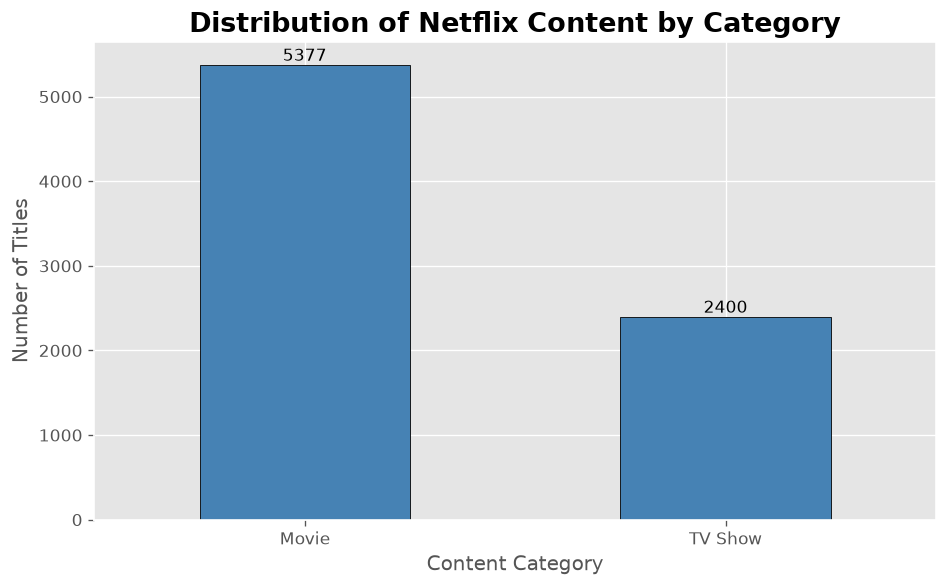

In [13]:
plot_count_bar(
    category_counts,
    title="Distribution of Netflix Content by Category",
    xlabel="Content Category",
    ylabel="Number of Titles"
)

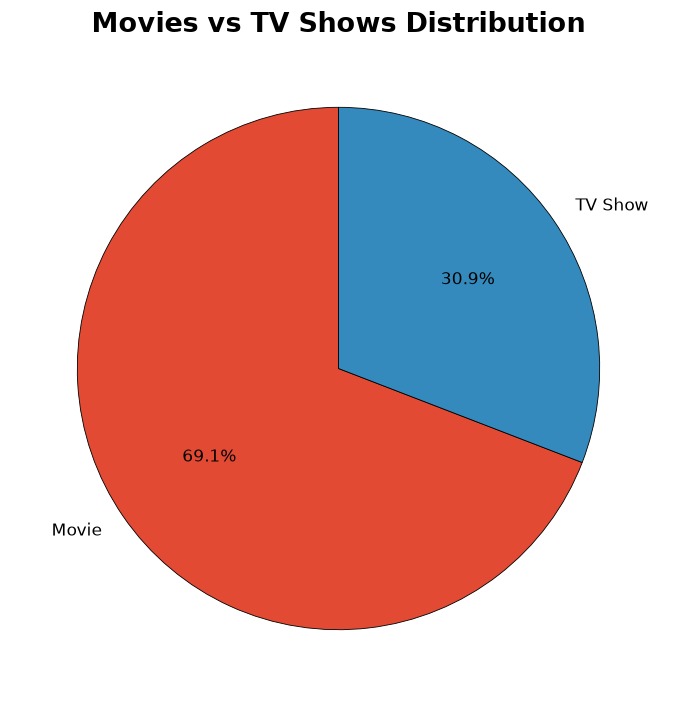

In [15]:
plot_pie_chart(
    category_counts,
    "Movies vs TV Shows Distribution"
)

##### Key Insights

- Movies account for **69.14%** of the Netflix catalog.
- TV Shows account for **30.86%** of the available content.
- Movies represent more than two-thirds of the total titles on the platform.
- The ratio of Movies to TV Shows is approximately **2.2 : 1**, indicating that Netflix maintains a significantly larger collection of films than episodic content.

##### Business Interpretation

The analysis indicates that Netflix's content library is predominantly composed of movies, suggesting a strategic emphasis on offering a broad selection of films across diverse genres and regions. Movies typically require less viewing commitment than multi-season television series, making them appealing to a wide audience with varied viewing preferences.

Although TV Shows represent a smaller share of the catalog, they remain an important component of the platform's content strategy, as serialized content often encourages longer viewer engagement and increases subscriber retention through continued viewing across multiple episodes and seasons.

##### Conclusion

Netflix's catalog is heavily skewed toward movies, which comprise approximately **69.14%** of all available titles, while TV Shows account for **30.86%**. This distribution suggests that the platform prioritizes offering an extensive movie library while maintaining a substantial collection of television series to support long-term user engagement. These findings provide a clear overview of Netflix's content composition and establish a foundation for further analyses of genres, release trends, and regional content distribution.

#### Investigation Question 2

##### Which genres or content types are most prevalent in Netflix's library?

###### Objective

The objective of this analysis is to identify the most common genres available in the Netflix catalog. Since each title can belong to multiple genres, the `Type` column contains comma-separated values representing different content categories.

To perform this analysis, the genres are separated into individual entries, allowing each genre to be counted independently. The resulting frequency distribution helps identify Netflix's dominant content categories and provides insights into the platform's content diversity.

##### Methodology

The analysis is carried out using the following steps:

1. Split the `Type` column into individual genres using the comma (`,`) separator.
2. Expand the list of genres so that each genre occupies its own row.
3. Remove any leading or trailing whitespace from the extracted genre names.
4. Count the occurrence of each genre.
5. Rank genres in descending order based on their frequency.
6. Visualize the top genres using a horizontal bar chart.
7. Interpret the findings to understand Netflix's content composition.

In [16]:
# Extract Individual Genres
genre_series = (
    df["Type"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

genre_series.head(10)

0    International TV Shows
0                 TV Dramas
0       TV Sci-Fi & Fantasy
1                    Dramas
1      International Movies
2             Horror Movies
2      International Movies
3        Action & Adventure
3        Independent Movies
3          Sci-Fi & Fantasy
Name: Type, dtype: str

In [17]:
genre_counts = (
    genre_series
    .value_counts()
)

genre_counts.head(20)

Type
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1198
Documentaries                786
Action & Adventure           721
TV Dramas                    703
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
TV Comedies                  518
Thrillers                    491
Crime TV Shows               426
Kids' TV                     412
Docuseries                   352
Romantic TV Shows            333
Stand-Up Comedy              329
Music & Musicals             321
Horror Movies                312
British TV Shows             231
Name: count, dtype: int64

In [18]:
genre_percentages = (
    genre_counts
    / genre_counts.sum()
    * 100
).round(2)

genre_percentages.head(20)

Type
International Movies        14.29
Dramas                      12.35
Comedies                     8.63
International TV Shows       7.03
Documentaries                4.61
Action & Adventure           4.23
TV Dramas                    4.12
Independent Movies           3.95
Children & Family Movies     3.12
Romantic Movies              3.11
TV Comedies                  3.04
Thrillers                    2.88
Crime TV Shows               2.50
Kids' TV                     2.42
Docuseries                   2.06
Romantic TV Shows            1.95
Stand-Up Comedy              1.93
Music & Musicals             1.88
Horror Movies                1.83
British TV Shows             1.35
Name: count, dtype: float64

In [22]:
genre_summary = pd.DataFrame({
    "Count": genre_counts,
    "Percentage (%)": genre_percentages
})

genre_summary.head(15)

genre_summary["Cumulative Percentage (%)"] = (
    genre_summary["Percentage (%)"].cumsum().round(2)
)

genre_summary.head(15)

,Count,Percentage (%),Cumulative Percentage (%)
Type,,,
International Movies,2437,14.29,14.29
Dramas,2106,12.35,26.64
Comedies,1471,8.63,35.27
International TV Shows,1198,7.03,42.30
Documentaries,786,4.61,46.91
Action & Adventure,721,4.23,51.14
TV Dramas,703,4.12,55.26
Independent Movies,673,3.95,59.21
Children & Family Movies,532,3.12,62.33


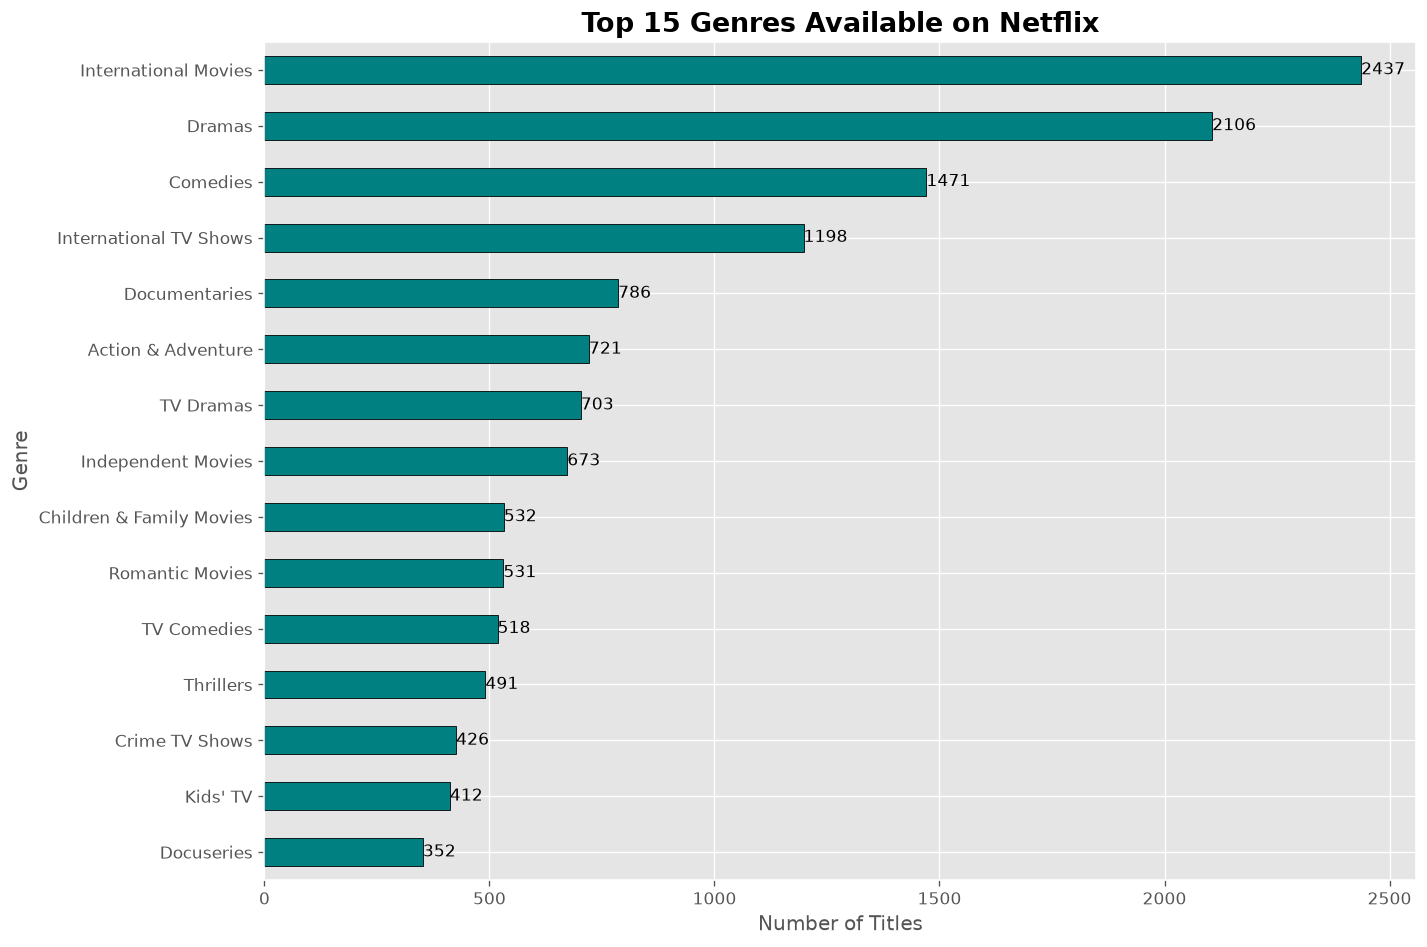

In [23]:
plot_horizontal_bar(
    genre_counts.head(15).sort_values(), # to display the bar in descending order
    title="Top 15 Genres Available on Netflix",
    xlabel="Number of Titles",
    ylabel="Genre"
)

##### Key Insights

- **International Movies** is the most prevalent genre on Netflix, with **2,437 titles**, accounting for **14.29%** of all genre occurrences.
- **Dramas** rank second with **2,106 titles (12.35%)**, highlighting the platform's strong emphasis on story-driven content.
- **Comedies** are the third most common genre, contributing **1,471 titles (8.63%)**, indicating consistent demand for light-hearted entertainment.
- **International TV Shows (7.03%)** and **Documentaries (4.61%)** also represent a significant portion of the catalog, demonstrating Netflix's investment in globally diverse and educational content.
- Genres such as **Action & Adventure**, **TV Dramas**, **Independent Movies**, **Children & Family Movies**, and **Romantic Movies** each contribute between **3% and 5%**, reflecting a well-balanced distribution across multiple audience preferences.
- Specialized genres such as **British TV Shows**, **Stand-Up Comedy**, **Music & Musicals**, and **Horror Movies** have comparatively smaller representations, suggesting that these genres serve niche audiences within the platform.

##### Business Interpretation

The genre distribution indicates that Netflix prioritizes content with broad global appeal. The dominance of **International Movies** suggests a strategic focus on expanding localized content to serve audiences across different countries and cultures.

The high representation of **Dramas** and **Comedies** reflects sustained viewer demand for emotionally engaging and universally relatable entertainment. At the same time, the strong presence of **International TV Shows** demonstrates Netflix's continued investment in serialized content that promotes long-term viewer engagement.

The diverse mix of documentaries, children's programming, romantic titles, and action-oriented content indicates that Netflix aims to cater to multiple audience segments rather than concentrating on a single genre. This diversified content portfolio reduces dependence on any one category and helps attract subscribers with varying interests.

##### Conclusion

Netflix's content library exhibits a diverse genre distribution, with **International Movies**, **Dramas**, and **Comedies** emerging as the dominant categories. The prominence of internationally produced content highlights Netflix's commitment to serving a global audience, while the balanced representation of other genres demonstrates a broad content strategy designed to satisfy a wide range of viewer preferences.

These findings provide valuable insight into Netflix's content acquisition and production priorities and establish a foundation for further analyses of regional content distribution, audience ratings, and temporal trends.

#### Investigation Question 3

##### How has Netflix's content volume changed over time (by release year)?

###### Objective

The objective of this analysis is to examine the growth of Netflix's content library over time by analyzing the number of titles released each year.

By extracting the release year from the `Release_Date` column and calculating the yearly content count, we can identify periods of rapid expansion, steady growth, or decline in the availability of movies and TV shows on the platform.

Understanding these temporal trends provides valuable insight into Netflix's content acquisition strategy and the evolution of its catalog over the years.

##### Methodology

The analysis is performed using the following steps:

1. Convert the `Release_Date` column to the datetime format.
2. Extract the release year from each title.
3. Group the dataset by release year.
4. Count the number of titles released each year.
5. Visualize the yearly distribution using a line chart.
6. Identify years with significant growth or decline.
7. Interpret the observed trends and their business implications.

In [24]:
df["Release_Date"] = pd.to_datetime(df["Release_Date"])

df["Release_Year"] = df["Release_Date"].dt.year

df[["Release_Date", "Release_Year"]].head()

,Release_Date,Release_Year
0,2020-08-14,2020
1,2016-12-23,2016
2,2018-12-20,2018
3,2017-11-16,2017
4,2020-01-01,2020


In [26]:
yearly_content = (
    df.groupby("Release_Year")
      .size()
      .sort_index()
)

yearly_content.head()

Release_Year
2008     2
2009     2
2010     1
2011    13
2012     3
dtype: int64

In [27]:
yearly_summary = pd.DataFrame({
    "Number of Titles": yearly_content
})

yearly_summary.head(15)

,Number of Titles
Release_Year,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,25
2015,88
2016,443


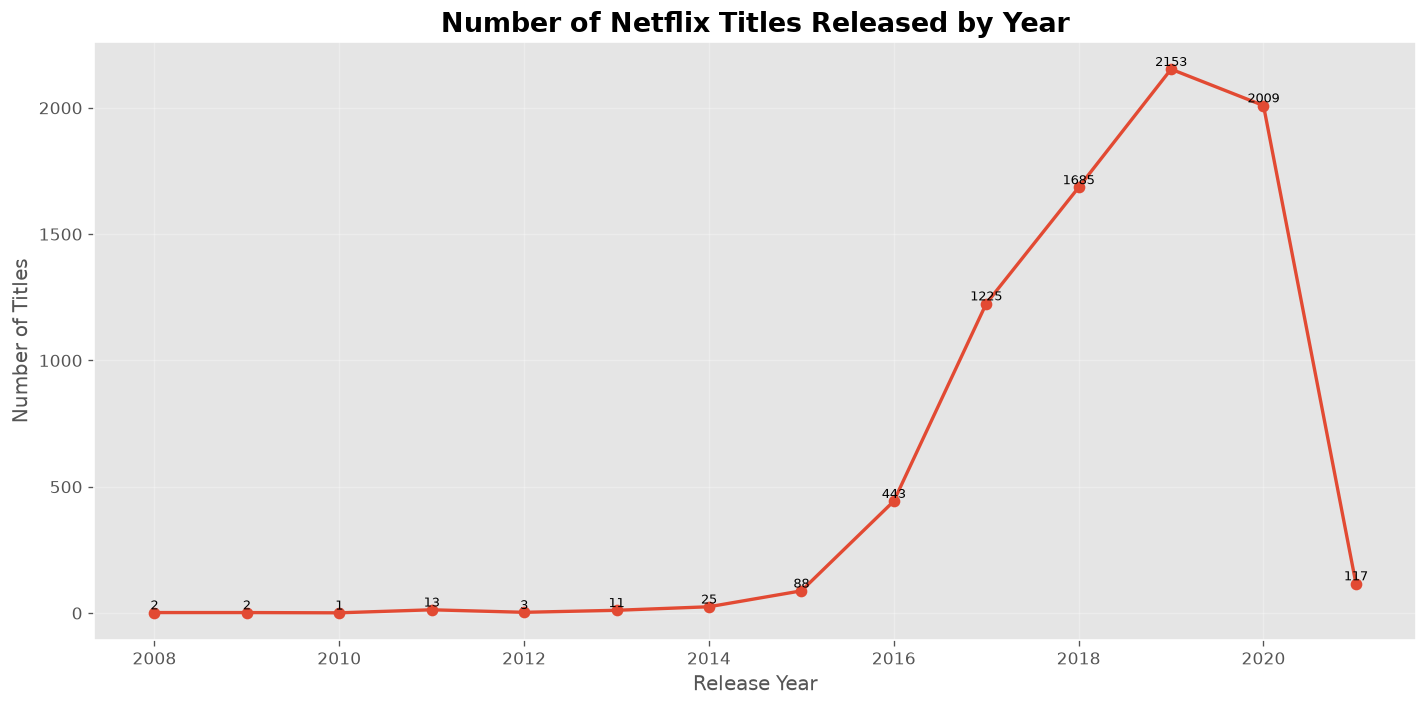

In [28]:
plot_line_chart(
    yearly_content,
    title="Number of Netflix Titles Released by Year",
    xlabel="Release Year",
    ylabel="Number of Titles"
)

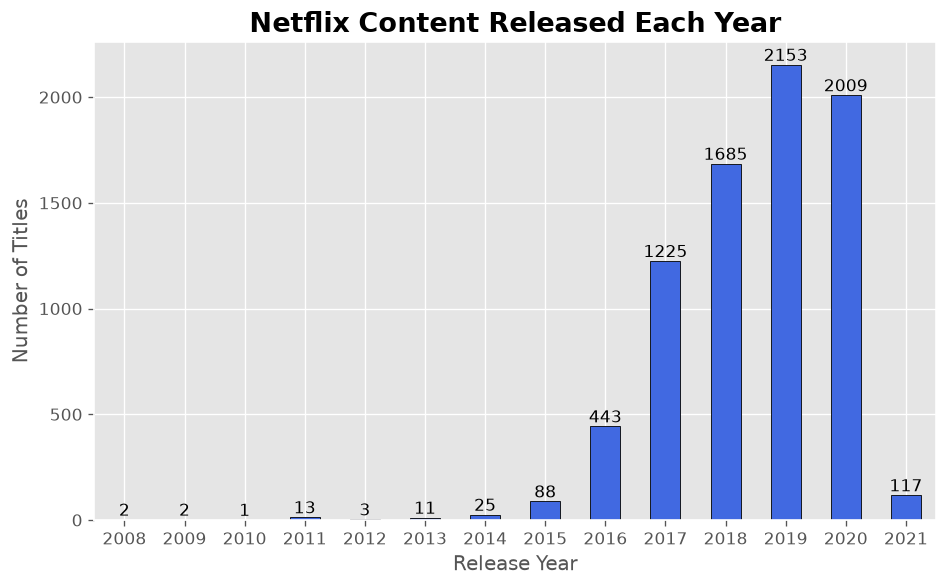

In [29]:
plot_count_bar(
    yearly_content,
    title="Netflix Content Released Each Year",
    xlabel="Release Year",
    ylabel="Number of Titles",
    color="royalblue"
)

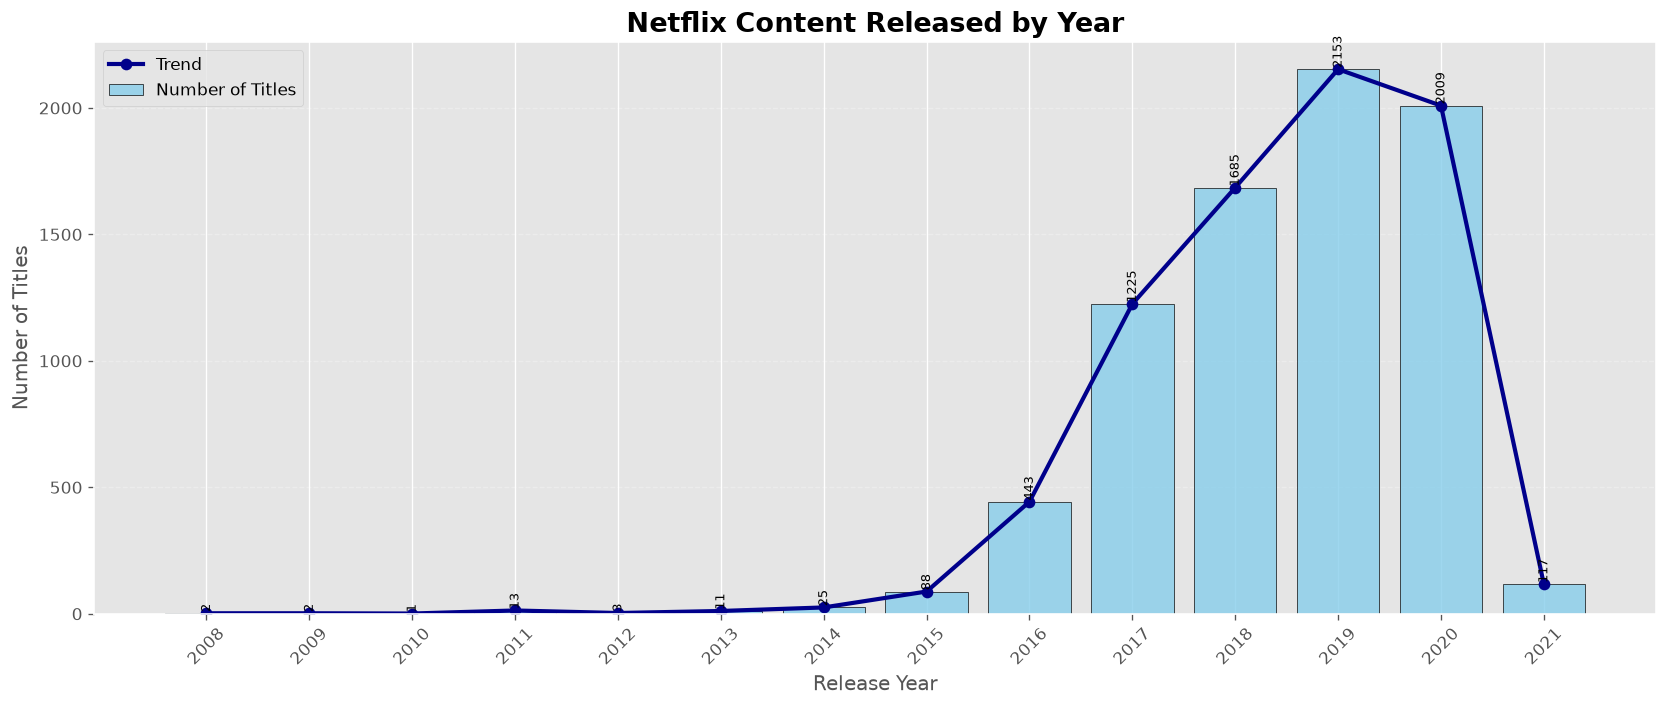

In [37]:
plot_bar_line_chart(
    yearly_content,
    title="Netflix Content Released by Year",
    xlabel="Release Year",
    ylabel="Number of Titles"
)

In [32]:
# Year with maximum releases
peak_year = yearly_content.idxmax()
peak_count = yearly_content.max()

# Year with minimum releases
lowest_year = yearly_content.idxmin()
lowest_count = yearly_content.min()

print(f"Peak Year   : {peak_year} ({peak_count} titles)")
print(f"Lowest Year : {lowest_year} ({lowest_count} titles)")

Peak Year   : 2019 (2153 titles)
Lowest Year : 2010 (1 titles)


In [33]:
yearly_summary.tail(10)

,Number of Titles
Release_Year,
2012,3
2013,11
2014,25
2015,88
2016,443
2017,1225
2018,1685
2019,2153
2020,2009


##### Key Insights

- Netflix's content library expanded significantly between **2015 and 2019**, indicating a period of aggressive content acquisition and production.
- The number of titles increased from **88 in 2015** to **2,153 in 2019**, representing the highest annual content volume in the dataset.
- The most rapid growth occurred between **2016 and 2019**, reflecting Netflix's large-scale investment in expanding its global content catalog.
- Although the number of titles decreased slightly in **2020** (2,009 titles), the platform continued to maintain a high volume of content releases.
- The sharp decline observed in **2021** should be interpreted cautiously, as it may be due to incomplete data collection rather than a genuine reduction in Netflix's content production.

##### Business Interpretation

The yearly release trend suggests that Netflix underwent a period of rapid expansion between 2015 and 2019. This growth aligns with the company's strategy of increasing investment in original productions, acquiring international content, and expanding into new global markets.

The sustained high number of releases in 2019 and 2020 demonstrates Netflix's commitment to maintaining a diverse and continuously growing content library. The apparent decline in 2021 is likely influenced by the time period covered by the dataset and should not be interpreted as a definitive decrease in Netflix's long-term content strategy.

Overall, the trend reflects Netflix's evolution from a streaming platform with a relatively small catalog to one of the world's largest providers of digital entertainment.

##### Conclusion

The analysis reveals a strong upward trend in Netflix's content releases from 2012 to 2019, culminating in a peak of **2,153 titles** in 2019. This growth highlights Netflix's aggressive expansion strategy and increasing investment in both licensed and original content.

While a slight decrease is observed in 2020 and a substantial drop appears in 2021, these findings should be interpreted within the context of the dataset's coverage period. Overall, the temporal analysis demonstrates Netflix's successful scaling of its content library over the past decade.

##### Investigation Question 4

##### Which countries produce the most content available on Netflix?

###### Objective

The objective of this analysis is to identify the countries that contribute the most content to Netflix's catalog. Since many titles are co-produced by multiple countries, the `Country` column contains comma-separated values.

By separating these values and counting each country individually, we can determine the leading content-producing countries and gain insights into Netflix's global content distribution and regional diversity.

##### Methodology

The analysis is performed using the following steps:

1. Remove missing values from the `Country` column.
2. Split multiple-country entries using the comma (`,`) separator.
3. Expand the list so that each country occupies a separate row.
4. Remove leading and trailing whitespace from country names.
5. Count the number of titles associated with each country.
6. Calculate the percentage contribution of each country.
7. Rank countries in descending order.
8. Visualize the top contributing countries using a horizontal bar chart.
9. Interpret the results and discuss Netflix's global content distribution.

In [38]:
country_series = (
    df["Country"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

country_series.head(10)

0           Brazil
1           Mexico
2        Singapore
3    United States
4    United States
5           Turkey
6            Egypt
7    United States
8            India
9            India
Name: Country, dtype: str

In [39]:
country_counts = (
    country_series
    .value_counts()
)

country_counts.head(20)

Country
United States     3291
India              990
United Kingdom     722
Unknown            506
Canada             412
France             349
Japan              286
Spain              215
South Korea        212
Germany            199
Mexico             154
China              147
Australia          143
Egypt              110
Turkey             108
Hong Kong          102
Italy               90
Brazil              88
Taiwan              85
Belgium             85
Name: count, dtype: int64

In [40]:
country_percentages = (
    country_counts
    .div(country_counts.sum())
    .mul(100)
    .round(2)
)

country_percentages.head(20)

Country
United States     34.41
India             10.35
United Kingdom     7.55
Unknown            5.29
Canada             4.31
France             3.65
Japan              2.99
Spain              2.25
South Korea        2.22
Germany            2.08
Mexico             1.61
China              1.54
Australia          1.50
Egypt              1.15
Turkey             1.13
Hong Kong          1.07
Italy              0.94
Brazil             0.92
Taiwan             0.89
Belgium            0.89
Name: count, dtype: float64

In [46]:
country_summary = pd.DataFrame({
    "Count": country_counts,
    "Percentage (%)": country_percentages
})

print(country_summary.head(20))

top5_percentage = country_summary.head(5)["Percentage (%)"].sum()

print(f"\nTop 5 countries contribute {top5_percentage:.2f}% of the catalog.")

                Count  Percentage (%)
Country                              
United States    3291           34.41
India             990           10.35
United Kingdom    722            7.55
Unknown           506            5.29
Canada            412            4.31
France            349            3.65
Japan             286            2.99
Spain             215            2.25
South Korea       212            2.22
Germany           199            2.08
Mexico            154            1.61
China             147            1.54
Australia         143            1.50
Egypt             110            1.15
Turkey            108            1.13
Hong Kong         102            1.07
Italy              90            0.94
Brazil             88            0.92
Taiwan             85            0.89
Belgium            85            0.89

Top 5 countries contribute 61.91% of the catalog.


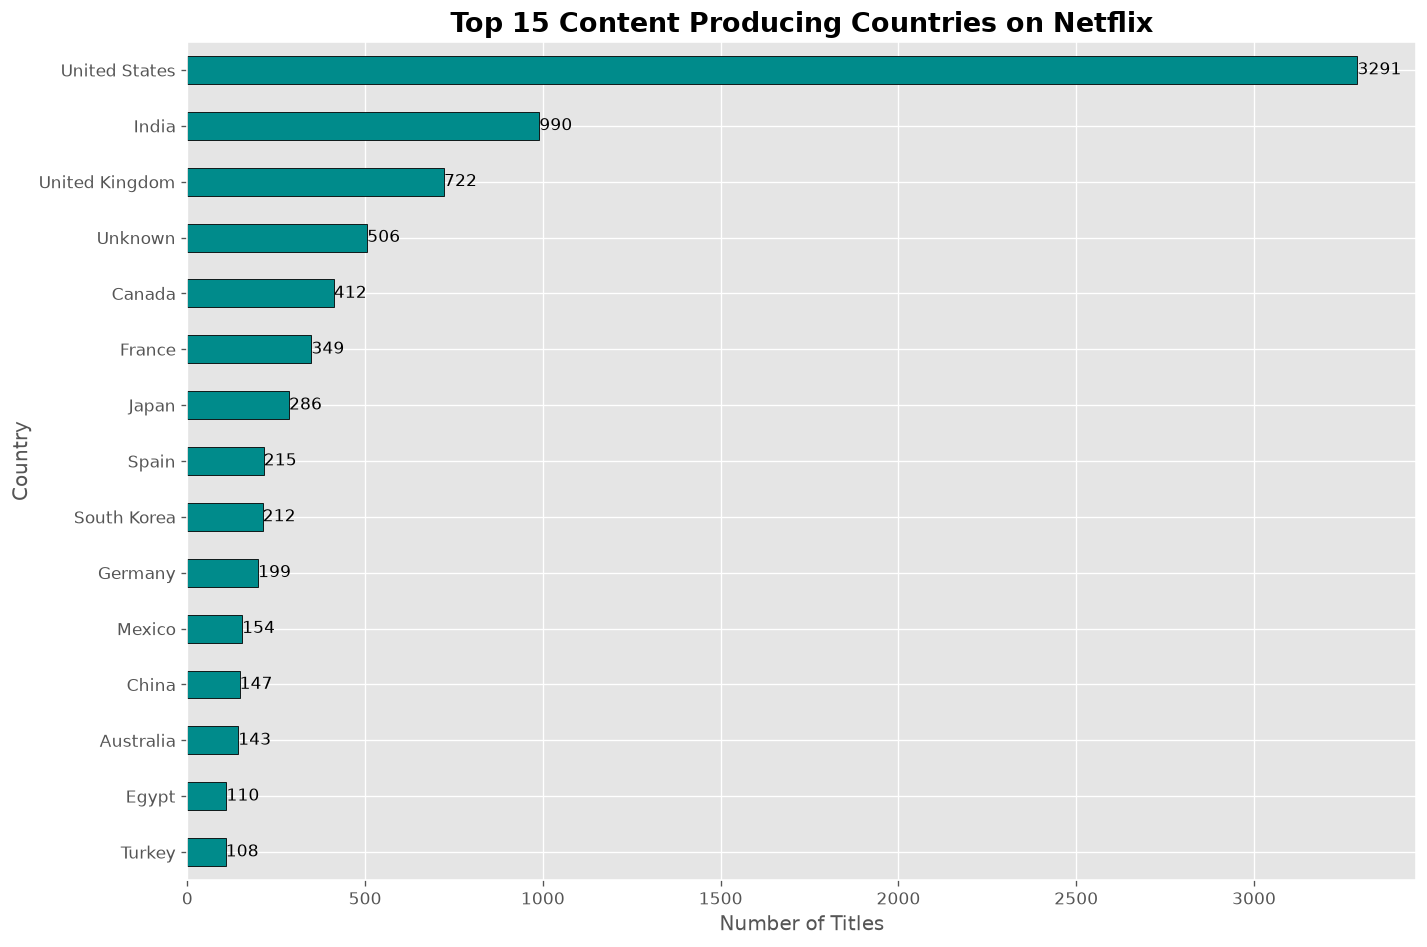

In [42]:
plot_horizontal_bar(
    country_counts.head(15).sort_values(),
    title="Top 15 Content Producing Countries on Netflix",
    xlabel="Number of Titles",
    ylabel="Country",
    color="darkcyan"
)

##### Key Insights

- The **United States** is the largest contributor to Netflix's content library, with **3,291 titles**, representing **34.41%** of all country occurrences.
- **India** ranks second with **990 titles (10.35%)**, highlighting Netflix's substantial investment in one of the world's largest entertainment industries.
- The **United Kingdom** contributes **722 titles (7.55%)**, making it the third-largest content-producing country on the platform.
- Entries labeled **"Unknown"** account for **506 titles (5.29%)**. These represent records where the country information is unavailable or missing and should not be interpreted as a geographical contributor.
- Other major contributors include **Canada (4.31%)**, **France (3.65%)**, **Japan (2.99%)**, **Spain (2.25%)**, and **South Korea (2.22%)**, demonstrating Netflix's strong international content portfolio.
- The distribution indicates that while the United States dominates the catalog, Netflix sources content from a diverse range of countries across North America, Europe, and Asia.

##### Business Interpretation

The country-wise distribution demonstrates Netflix's strategy of maintaining a globally diverse content library while relying heavily on major entertainment markets. The United States contributes over one-third of the catalog, reflecting its position as Netflix's primary content source and one of the world's largest film and television production hubs.

The strong representation of countries such as India, the United Kingdom, Canada, France, Japan, and South Korea highlights Netflix's continued investment in international content. This diversified acquisition strategy enables the platform to appeal to regional audiences while expanding the global reach of locally produced titles.

The presence of records with unknown country information emphasizes the importance of complete metadata in streaming platforms, as missing production details can limit the accuracy of geographical analyses.

##### Conclusion

The analysis reveals that Netflix's content library is geographically diverse but remains strongly centered around the **United States**, which contributes approximately **34.41%** of all catalog entries. Significant contributions from **India**, the **United Kingdom**, **Canada**, **France**, and several Asian countries demonstrate Netflix's commitment to delivering internationally diverse content.

Although a small proportion of titles have missing country information, the overall distribution confirms that Netflix follows a global content acquisition strategy designed to serve audiences across multiple regions and cultures.

### Overall Findings

The univariate analysis provided a comprehensive understanding of the individual characteristics of the Netflix dataset by examining each key variable independently. The analysis addressed four investigation questions related to content categories, genres, release trends, and country-wise content distribution.

The major findings are summarized below:

- Movies dominate Netflix's catalog, accounting for **69.14%** of all titles, while **TV Shows** represent **30.86%**, indicating a stronger emphasis on feature-length content.
- **International Movies**, **Dramas**, and **Comedies** emerged as the three most prevalent genres, reflecting Netflix's strategy of providing diverse entertainment with broad global appeal.
- Netflix experienced rapid catalog growth between **2015 and 2019**, reaching its highest annual content volume in **2019**, before showing a slight decline in **2020** and a sharp reduction in **2021**, which is likely influenced by the dataset's coverage period.
- The **United States** remains the largest contributor to Netflix's content library, followed by **India** and the **United Kingdom**, highlighting Netflix's strong presence in major entertainment markets while maintaining a globally diverse catalog.

Overall, the univariate analysis establishes a clear understanding of Netflix's content composition, growth patterns, genre diversity, and geographical distribution, providing a strong foundation for investigating relationships between multiple variables in the next stage of the analysis.

### Business Recommendations

Based on the findings obtained from the univariate analysis, the following recommendations can be considered:

##### 1. Continue Investing in International Content

The dominance of International Movies demonstrates strong global demand for localized content. Expanding partnerships with regional production houses can further strengthen Netflix's international subscriber base.

##### 2. Maintain a Balanced Content Portfolio

While movies dominate the catalog, TV Shows remain essential for long-term viewer engagement. Maintaining an appropriate balance between films and serialized content can help maximize both audience reach and subscriber retention.

##### 3. Expand High-Performing Genres

Genres such as Dramas, Comedies, and International TV Shows consistently appear among the most common categories. Continued investment in these genres is likely to align with existing viewer preferences while supporting sustained platform engagement.

##### 4. Increase Regional Content Diversity

Although the United States contributes the largest share of Netflix's catalog, increasing investments in emerging entertainment markets may improve regional representation and attract new audiences across different geographical locations.

##### 5. Improve Metadata Quality

The presence of titles with unknown country information suggests opportunities to improve metadata completeness. Accurate content metadata enhances recommendation systems, search functionality, and analytical reporting.

### Summary of Univariate Analysis

The univariate exploratory data analysis successfully examined the distribution of individual variables within the Netflix dataset without considering relationships between them.

The analysis revealed important characteristics regarding:

- Content category distribution
- Genre popularity
- Temporal growth of Netflix's catalog
- Country-wise content production

These insights provide valuable context for understanding the overall structure of the dataset. However, they do not explain how different variables interact with one another.

The next stage of the analysis focuses on **Bivariate Exploratory Data Analysis (EDA)**, where relationships between pairs of variables will be explored to answer more advanced analytical questions, such as how content ratings vary across genres and whether specific genres are concentrated within particular countries.
